### Cell 1: Setup and load

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# Paths
DATA_DIR = Path('../data/processed')
RESULTS_DIR = Path('../results')
TABLES_DIR = RESULTS_DIR / 'tables'
FIGURES_DIR = RESULTS_DIR / 'figures'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_CV_FOLDS = 5

# Load encoded permissive data (matches Phase 2 canonical baseline)
df_encoded = pd.read_csv(DATA_DIR / 'metabric_permissive_encoded.csv')

# Load canonical split
splits = pd.read_csv(DATA_DIR / 'split_indices.csv')
train_idx = splits['permissive_train'].dropna().astype(int).values
test_idx = splits['permissive_test'].dropna().astype(int).values

X = df_encoded.drop(columns=['Relapse Free Status']).astype(float)
y = df_encoded['Relapse Free Status'].astype(int)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Feature columns: {X_train.columns.tolist()}")

Training set: (1576, 39)
Test set: (394, 39)
Feature columns: ['Age at Diagnosis', 'Cellularity', 'G-Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'Tumor Size(mm)', 'Type of Breast Surgery_Breast Conserving', 'Type of Breast Surgery_Mastectomy', 'Chemotherapy_No', 'Chemotherapy_Yes', 'Pam50 + Claudin-low subtype_Basal', 'Pam50 + Claudin-low subtype_Her2', 'Pam50 + Claudin-low subtype_LumA', 'Pam50 + Claudin-low subtype_LumB', 'Pam50 + Claudin-low subtype_Normal', 'Pam50 + Claudin-low subtype_claudin-low', 'ER Status_Negative', 'ER Status_Positive', 'HER2 Status_Negative', 'HER2 Status_Positive', 'Tumor Other Histologic Subtype_Ductal/NST', 'Tumor Other Histologic Subtype_Lobular', 'Tumor Other Histologic Subtype_Medullary', 'Tumor Other Histologic Subtype_Metaplastic', 'Tumor Other Histologic Subtype_Mixed', 'Tumor Other Histologic Subtype_Mucinous', 'Tumor Other Histologic Subtype_Other', 'Tumor Other Histologic Subtype_T

### Cell 2: Identify feature indices for monotonic constraints

In [2]:
# === Identify column indices for the features we want to constrain ===
# HistGradientBoostingClassifier takes monotonic_cst as an array of length n_features
# where 0 = no constraint, 1 = monotonic increase, -1 = monotonic decrease
# The direction here is: feature value increases → predicted recurrence probability increases

# We're constraining toward MORE recurrence risk for these features
features_to_constrain_increase = {
    'Lymph nodes examined positive': 'Lymph nodes (more nodes → higher risk)',
    'Tumor Size(mm)': 'Tumor size (larger → higher risk)',
    'G-Neoplasm Histologic Grade': 'Histologic grade (higher grade → higher risk)',
}

# Verify these column names exist in our encoded data
for col in features_to_constrain_increase:
    assert col in X_train.columns, f"Column '{col}' not found in encoded data"
    print(f"  {col}: column index {X_train.columns.get_loc(col)}")

# Build the constraint vectors
n_features = X_train.shape[1]

# Configuration 1: unconstrained (canonical baseline equivalent, but using HistGradientBoosting)
constraints_none = [0] * n_features

# Configuration 2: lymph nodes only
constraints_ln = [0] * n_features
constraints_ln[X_train.columns.get_loc('Lymph nodes examined positive')] = 1

# Configuration 3: full prognostic set
constraints_full = [0] * n_features
for col in features_to_constrain_increase:
    constraints_full[X_train.columns.get_loc(col)] = 1

print(f"\nUnconstrained: 0 monotonic constraints")
print(f"Lymph nodes only: {sum(1 for c in constraints_ln if c != 0)} constraint(s)")
print(f"Full prognostic set: {sum(1 for c in constraints_full if c != 0)} constraints")

  Lymph nodes examined positive: column index 3
  Tumor Size(mm): column index 6
  G-Neoplasm Histologic Grade: column index 2

Unconstrained: 0 monotonic constraints
Lymph nodes only: 1 constraint(s)
Full prognostic set: 3 constraints


### Cell 3: Helper for evaluation

In [3]:
def evaluate_monotonic(constraints, model_name, notes=""):
    """Train HistGBM with given constraints, return metrics dict."""
    model = HistGradientBoostingClassifier(
        learning_rate=0.01,
        max_depth=3,
        max_iter=200,  # equivalent to n_estimators
        monotonic_cst=constraints,
        random_state=RANDOM_STATE,
    )
    
    # CV on training set
    cv_splitter = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv_splitter, scoring='accuracy')
    cv_recall = cross_val_score(model, X_train, y_train, cv=cv_splitter, scoring='recall')
    
    # Fit on full training set, evaluate on test
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    return {
        'model': model_name,
        'notes': notes,
        'cv_accuracy_mean': cv_acc.mean(),
        'cv_accuracy_std': cv_acc.std(),
        'cv_recall_mean': cv_recall.mean(),
        'cv_recall_std': cv_recall.std(),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_recall_recurrence': recall_score(y_test, y_pred, pos_label=1),
        'test_precision_recurrence': precision_score(y_test, y_pred, pos_label=1),
        'test_f1_recurrence': f1_score(y_test, y_pred, pos_label=1),
        'test_true_neg': tn, 'test_false_pos': fp,
        'test_false_neg': fn, 'test_true_pos': tp,
    }, model


def print_metrics(m):
    print(f"\n{'='*60}")
    print(f"  {m['model']}")
    if m['notes']:
        print(f"  ({m['notes']})")
    print('='*60)
    print(f"  CV accuracy: {m['cv_accuracy_mean']:.3f} ± {m['cv_accuracy_std']:.3f}")
    print(f"  CV recall:   {m['cv_recall_mean']:.3f} ± {m['cv_recall_std']:.3f}")
    print(f"  Test accuracy: {m['test_accuracy']:.3f}")
    print(f"  Test recall:   {m['test_recall_recurrence']:.3f}")
    print(f"  Test precision: {m['test_precision_recurrence']:.3f}")
    print(f"  Test F1:       {m['test_f1_recurrence']:.3f}")
    print(f"  Confusion: TN={m['test_true_neg']}, FP={m['test_false_pos']}, "
          f"FN={m['test_false_neg']}, TP={m['test_true_pos']}")


all_results = []

### Cell 4: Run the three configurations

In [4]:
# === Run the three configurations ===

m_unconstrained, model_unconstrained = evaluate_monotonic(
    constraints_none,
    "HistGBM (unconstrained)",
    "Reference: same model class as constrained versions, no constraints",
)
print_metrics(m_unconstrained)
all_results.append(m_unconstrained)

m_ln, model_ln = evaluate_monotonic(
    constraints_ln,
    "HistGBM (lymph nodes monotonic)",
    "Single high-confidence constraint",
)
print_metrics(m_ln)
all_results.append(m_ln)

m_full, model_full = evaluate_monotonic(
    constraints_full,
    "HistGBM (full prognostic monotonic)",
    "Lymph nodes + Tumor Size + Histologic Grade",
)
print_metrics(m_full)
all_results.append(m_full)

# Save the three trained models for reference (the lymph-nodes-only model
# will be used in the missingness sweep below)
with open(RESULTS_DIR / 'models' / 'monotonic_lymphnodes.pkl', 'wb') as f:
    pickle.dump({
        'model': model_ln,
        'features': X_train.columns.tolist(),
        'constraints': constraints_ln,
    }, f)


  HistGBM (unconstrained)
  (Reference: same model class as constrained versions, no constraints)
  CV accuracy: 0.640 ± 0.028
  CV recall:   0.306 ± 0.026
  Test accuracy: 0.665
  Test recall:   0.325
  Test precision: 0.684
  Test F1:       0.441
  Confusion: TN=210, FP=24, FN=108, TP=52

  HistGBM (lymph nodes monotonic)
  (Single high-confidence constraint)
  CV accuracy: 0.646 ± 0.025
  CV recall:   0.319 ± 0.023
  Test accuracy: 0.668
  Test recall:   0.325
  Test precision: 0.693
  Test F1:       0.443
  Confusion: TN=211, FP=23, FN=108, TP=52

  HistGBM (full prognostic monotonic)
  (Lymph nodes + Tumor Size + Histologic Grade)
  CV accuracy: 0.643 ± 0.028
  CV recall:   0.317 ± 0.018
  Test accuracy: 0.668
  Test recall:   0.319
  Test precision: 0.699
  Test F1:       0.438
  Confusion: TN=212, FP=22, FN=109, TP=51


### Cell 5: Monotonicity-violation analysis

In [5]:
# === Monotonicity-violation analysis ===
# How often does the unconstrained model produce predictions that violate clinical monotonicity?
# We test this by constructing pairs of synthetic patients where one has a higher
# value of a constrained feature, and check whether the predicted recurrence probability
# also goes up.

print("="*60)
print("  MONOTONICITY-VIOLATION ANALYSIS")
print("="*60)
print("Testing whether the unconstrained model produces predictions that")
print("violate clinical monotonicity (e.g., higher lymph node count predicts")
print("LOWER recurrence risk for an otherwise-identical patient).")
print()

def count_monotonic_violations(model, feature_name, n_trials=500):
    np.random.seed(RANDOM_STATE)
    feature_idx = X_train.columns.get_loc(feature_name)
    sample_indices = np.random.choice(len(X_test), size=min(n_trials, len(X_test)), replace=False)
    
    violations = 0
    valid_pairs = 0
    for i in sample_indices:
        original = X_test.iloc[[i]].copy()  # keep as DataFrame, note double brackets
        modified = original.copy()
        modified.iloc[0, feature_idx] = original.iloc[0, feature_idx] + 1.0
        
        prob_original = model.predict_proba(original)[0, 1]
        prob_modified = model.predict_proba(modified)[0, 1]
        
        if prob_modified < prob_original - 1e-6:
            violations += 1
        valid_pairs += 1
    
    return violations, valid_pairs


# Test each constrained feature on the unconstrained model
print("Unconstrained model — monotonicity violations:")
for feat in features_to_constrain_increase:
    v, n = count_monotonic_violations(model_unconstrained, feat)
    print(f"  {feat}: {v}/{n} patient pairs ({100*v/n:.1f}%) violate monotonicity")

print()
print("Lymph-nodes-constrained model — monotonicity violations:")
v, n = count_monotonic_violations(model_ln, 'Lymph nodes examined positive')
print(f"  Lymph nodes examined positive: {v}/{n} patient pairs ({100*v/n:.1f}%)")

print()
print("Full-prognostic-constrained model — monotonicity violations:")
for feat in features_to_constrain_increase:
    v, n = count_monotonic_violations(model_full, feat)
    print(f"  {feat}: {v}/{n} patient pairs ({100*v/n:.1f}%)")

  MONOTONICITY-VIOLATION ANALYSIS
Testing whether the unconstrained model produces predictions that
violate clinical monotonicity (e.g., higher lymph node count predicts
LOWER recurrence risk for an otherwise-identical patient).

Unconstrained model — monotonicity violations:
  Lymph nodes examined positive: 5/394 patient pairs (1.3%) violate monotonicity
  Tumor Size(mm): 45/394 patient pairs (11.4%) violate monotonicity
  G-Neoplasm Histologic Grade: 0/394 patient pairs (0.0%) violate monotonicity

Lymph-nodes-constrained model — monotonicity violations:
  Lymph nodes examined positive: 0/394 patient pairs (0.0%)

Full-prognostic-constrained model — monotonicity violations:
  Lymph nodes examined positive: 0/394 patient pairs (0.0%)
  Tumor Size(mm): 0/394 patient pairs (0.0%)
  G-Neoplasm Histologic Grade: 0/394 patient pairs (0.0%)


In [6]:
# === Save monotonicity violations as a clean table for the memo ===

violations_table = pd.DataFrame([
    {
        'Feature': 'Lymph nodes',
        'Unconstrained violations': '5/394 (1.3%)',
        'Lymph-nodes constrained': '0/394 (0.0%)',
        'Full prognostic constrained': '0/394 (0.0%)',
    },
    {
        'Feature': 'Tumor Size',
        'Unconstrained violations': '45/394 (11.4%)',
        'Lymph-nodes constrained': 'not constrained',
        'Full prognostic constrained': '0/394 (0.0%)',
    },
    {
        'Feature': 'Histologic Grade',
        'Unconstrained violations': '0/394 (0.0%)',
        'Lymph-nodes constrained': 'not constrained',
        'Full prognostic constrained': '0/394 (0.0%)',
    },
])

violations_table.to_csv(TABLES_DIR / 'monotonicity_violations.csv', index=False)
print("Monotonicity violations comparison:")
print(violations_table.to_string(index=False))
print()
print(f"Saved to {TABLES_DIR / 'monotonicity_violations.csv'}")
print()
print("Note: 'not constrained' means the constraint set in that configuration didn't")
print("include this feature, so violations are mathematically equivalent to the")
print("unconstrained model — not a separate experimental measurement.")

Monotonicity violations comparison:
         Feature Unconstrained violations Lymph-nodes constrained Full prognostic constrained
     Lymph nodes             5/394 (1.3%)            0/394 (0.0%)                0/394 (0.0%)
      Tumor Size           45/394 (11.4%)         not constrained                0/394 (0.0%)
Histologic Grade             0/394 (0.0%)         not constrained                0/394 (0.0%)

Saved to ..\results\tables\monotonicity_violations.csv

Note: 'not constrained' means the constraint set in that configuration didn't
include this feature, so violations are mathematically equivalent to the
unconstrained model — not a separate experimental measurement.


### Cell 6: Missingness robustness sweep

In [7]:
# === Missingness robustness sweep ===
# Progressively add missingness to constrained features and compare
# constrained vs unconstrained model performance.

print("="*60)
print("  MISSINGNESS ROBUSTNESS SWEEP")
print("="*60)
print("Adding missingness artificially to test whether constrained models")
print("degrade more gracefully than unconstrained ones.")
print()

def add_missingness_then_impute(X, feature_indices, missing_rate, seed):
    """
    Set values to NaN at the given rate for specified features,
    then median-impute (mimicking permissive cleaning behavior).
    """
    rng = np.random.default_rng(seed)
    X_corrupted = X.copy()
    
    for fidx in feature_indices:
        n_to_corrupt = int(len(X_corrupted) * missing_rate)
        rows_to_corrupt = rng.choice(len(X_corrupted), size=n_to_corrupt, replace=False)
        X_corrupted.iloc[rows_to_corrupt, fidx] = np.nan
    
    # Median-impute (using training set median to avoid leakage)
    for fidx in feature_indices:
        col_name = X_corrupted.columns[fidx]
        train_median = X_train.iloc[:, fidx].median()
        X_corrupted[col_name] = X_corrupted[col_name].fillna(train_median)
    
    return X_corrupted


# Sweep settings
missing_rates = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
constrained_feature_indices = [
    X_train.columns.get_loc(f) for f in features_to_constrain_increase
]

# We'll only corrupt the lymph nodes feature for this sweep (matches Week 6 setup —
# constraint operates on a single feature, sweep adds missingness to that feature)
ln_idx = X_train.columns.get_loc('Lymph nodes examined positive')

sweep_results = []

for rate in missing_rates:
    # Use multiple random seeds for the corruption to get error bars
    accuracies_unc = []
    accuracies_ln = []
    recalls_unc = []
    recalls_ln = []
    
    for seed in range(5):  # 5 different random corruptions per rate
        X_train_corrupt = add_missingness_then_impute(
            X_train, [ln_idx], rate, seed=seed
        )
        X_test_corrupt = add_missingness_then_impute(
            X_test, [ln_idx], rate, seed=seed + 1000
        )
        
        # Unconstrained
        m = HistGradientBoostingClassifier(
            learning_rate=0.01, max_depth=3, max_iter=200,
            random_state=RANDOM_STATE,
        )
        m.fit(X_train_corrupt, y_train)
        y_pred = m.predict(X_test_corrupt)
        accuracies_unc.append(accuracy_score(y_test, y_pred))
        recalls_unc.append(recall_score(y_test, y_pred, pos_label=1))
        
        # Constrained (lymph nodes only)
        m = HistGradientBoostingClassifier(
            learning_rate=0.01, max_depth=3, max_iter=200,
            monotonic_cst=constraints_ln,
            random_state=RANDOM_STATE,
        )
        m.fit(X_train_corrupt, y_train)
        y_pred = m.predict(X_test_corrupt)
        accuracies_ln.append(accuracy_score(y_test, y_pred))
        recalls_ln.append(recall_score(y_test, y_pred, pos_label=1))
    
    sweep_results.append({
        'missing_rate': rate,
        'unconstrained_acc_mean': np.mean(accuracies_unc),
        'unconstrained_acc_std': np.std(accuracies_unc),
        'constrained_acc_mean': np.mean(accuracies_ln),
        'constrained_acc_std': np.std(accuracies_ln),
        'unconstrained_recall_mean': np.mean(recalls_unc),
        'unconstrained_recall_std': np.std(recalls_unc),
        'constrained_recall_mean': np.mean(recalls_ln),
        'constrained_recall_std': np.std(recalls_ln),
    })
    
    print(f"  Rate {rate:.2f}: "
          f"unc acc={np.mean(accuracies_unc):.3f}±{np.std(accuracies_unc):.3f}, "
          f"con acc={np.mean(accuracies_ln):.3f}±{np.std(accuracies_ln):.3f}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df.to_csv(TABLES_DIR / 'monotonic_missingness_sweep.csv', index=False)

  MISSINGNESS ROBUSTNESS SWEEP
Adding missingness artificially to test whether constrained models
degrade more gracefully than unconstrained ones.

  Rate 0.00: unc acc=0.665±0.000, con acc=0.668±0.000
  Rate 0.05: unc acc=0.662±0.006, con acc=0.663±0.005
  Rate 0.10: unc acc=0.658±0.007, con acc=0.659±0.004
  Rate 0.15: unc acc=0.661±0.005, con acc=0.665±0.007
  Rate 0.20: unc acc=0.664±0.008, con acc=0.665±0.008
  Rate 0.30: unc acc=0.665±0.004, con acc=0.668±0.004
  Rate 0.50: unc acc=0.667±0.008, con acc=0.671±0.006


### Cell 7: Plot the missingness sweep

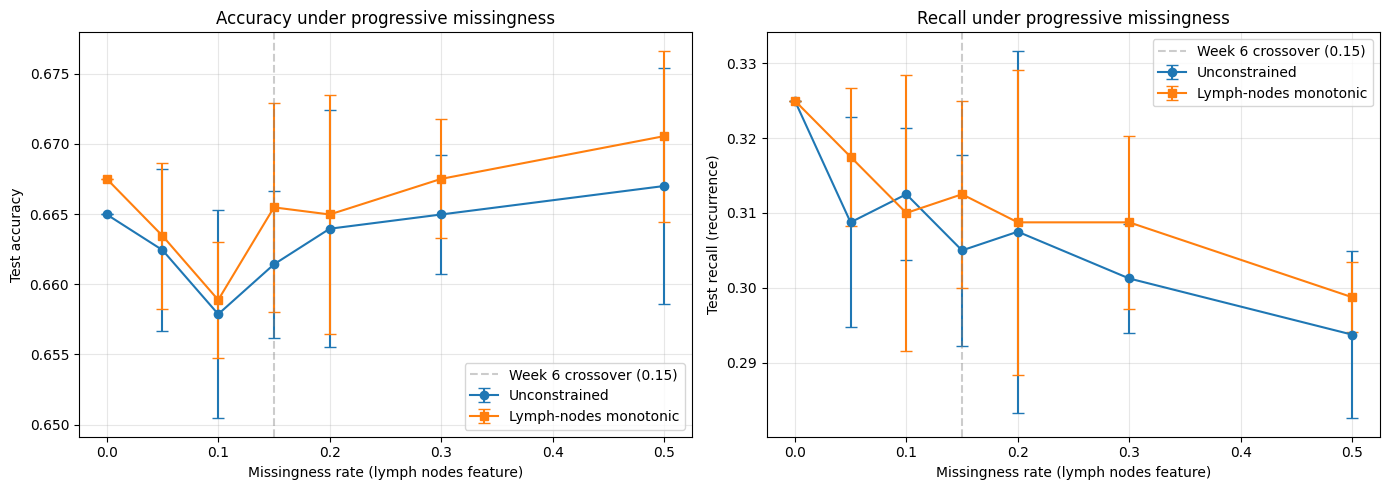

Saved figure to ..\results\figures\monotonic_robustness.png


In [8]:
# === Plot the missingness sweep ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.errorbar(
    sweep_df['missing_rate'], sweep_df['unconstrained_acc_mean'],
    yerr=sweep_df['unconstrained_acc_std'],
    label='Unconstrained', marker='o', capsize=4,
)
ax1.errorbar(
    sweep_df['missing_rate'], sweep_df['constrained_acc_mean'],
    yerr=sweep_df['constrained_acc_std'],
    label='Lymph-nodes monotonic', marker='s', capsize=4,
)
ax1.axvline(0.15, ls='--', alpha=0.4, color='gray', label='Week 6 crossover (0.15)')
ax1.set_xlabel('Missingness rate (lymph nodes feature)')
ax1.set_ylabel('Test accuracy')
ax1.set_title('Accuracy under progressive missingness')
ax1.legend()
ax1.grid(alpha=0.3)

# Recall plot
ax2.errorbar(
    sweep_df['missing_rate'], sweep_df['unconstrained_recall_mean'],
    yerr=sweep_df['unconstrained_recall_std'],
    label='Unconstrained', marker='o', capsize=4,
)
ax2.errorbar(
    sweep_df['missing_rate'], sweep_df['constrained_recall_mean'],
    yerr=sweep_df['constrained_recall_std'],
    label='Lymph-nodes monotonic', marker='s', capsize=4,
)
ax2.axvline(0.15, ls='--', alpha=0.4, color='gray', label='Week 6 crossover (0.15)')
ax2.set_xlabel('Missingness rate (lymph nodes feature)')
ax2.set_ylabel('Test recall (recurrence)')
ax2.set_title('Recall under progressive missingness')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'monotonic_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved figure to {FIGURES_DIR / 'monotonic_robustness.png'}")

### Cell 6b Missingness sweep revised without imputation

In [9]:
# === Missingness robustness sweep (revised) ===
# Use HistGBM's native NaN handling instead of median imputation.
# This tests what happens when the model actually sees missing values,
# not when missing values are smoothed over by imputation.

def add_real_missingness(X, feature_indices, missing_rate, seed):
    """Set values to NaN at the given rate. No imputation — let the model handle it."""
    rng = np.random.default_rng(seed)
    X_corrupted = X.copy()
    for fidx in feature_indices:
        n_to_corrupt = int(len(X_corrupted) * missing_rate)
        rows_to_corrupt = rng.choice(len(X_corrupted), size=n_to_corrupt, replace=False)
        X_corrupted.iloc[rows_to_corrupt, fidx] = np.nan
    return X_corrupted


print("="*60)
print("  MISSINGNESS ROBUSTNESS SWEEP (REVISED)")
print("="*60)
print("Using HistGBM's native NaN handling instead of median imputation.")
print("This better tests the missingness-robustness claim: the model sees")
print("actual missing values and must handle them rather than receiving")
print("smoothed-over imputed values.")
print()

ln_idx = X_train.columns.get_loc('Lymph nodes examined positive')
sweep_results_native = []

for rate in missing_rates:
    accuracies_unc, accuracies_ln = [], []
    recalls_unc, recalls_ln = [], []
    
    for seed in range(5):
        X_train_corrupt = add_real_missingness(X_train, [ln_idx], rate, seed=seed)
        X_test_corrupt = add_real_missingness(X_test, [ln_idx], rate, seed=seed + 1000)
        
        # Unconstrained
        m = HistGradientBoostingClassifier(
            learning_rate=0.01, max_depth=3, max_iter=200, random_state=RANDOM_STATE,
        )
        m.fit(X_train_corrupt, y_train)
        y_pred = m.predict(X_test_corrupt)
        accuracies_unc.append(accuracy_score(y_test, y_pred))
        recalls_unc.append(recall_score(y_test, y_pred, pos_label=1))
        
        # Constrained
        m = HistGradientBoostingClassifier(
            learning_rate=0.01, max_depth=3, max_iter=200,
            monotonic_cst=constraints_ln, random_state=RANDOM_STATE,
        )
        m.fit(X_train_corrupt, y_train)
        y_pred = m.predict(X_test_corrupt)
        accuracies_ln.append(accuracy_score(y_test, y_pred))
        recalls_ln.append(recall_score(y_test, y_pred, pos_label=1))
    
    sweep_results_native.append({
        'missing_rate': rate,
        'unconstrained_acc_mean': np.mean(accuracies_unc),
        'unconstrained_acc_std': np.std(accuracies_unc),
        'constrained_acc_mean': np.mean(accuracies_ln),
        'constrained_acc_std': np.std(accuracies_ln),
        'unconstrained_recall_mean': np.mean(recalls_unc),
        'unconstrained_recall_std': np.std(recalls_unc),
        'constrained_recall_mean': np.mean(recalls_ln),
        'constrained_recall_std': np.std(recalls_ln),
    })
    
    print(f"  Rate {rate:.2f}: "
          f"unc acc={np.mean(accuracies_unc):.3f}±{np.std(accuracies_unc):.3f}, "
          f"con acc={np.mean(accuracies_ln):.3f}±{np.std(accuracies_ln):.3f}")

sweep_df_native = pd.DataFrame(sweep_results_native)
sweep_df_native.to_csv(TABLES_DIR / 'monotonic_missingness_sweep_native.csv', index=False)

  MISSINGNESS ROBUSTNESS SWEEP (REVISED)
Using HistGBM's native NaN handling instead of median imputation.
This better tests the missingness-robustness claim: the model sees
actual missing values and must handle them rather than receiving
smoothed-over imputed values.

  Rate 0.00: unc acc=0.665±0.000, con acc=0.668±0.000
  Rate 0.05: unc acc=0.662±0.003, con acc=0.664±0.003
  Rate 0.10: unc acc=0.657±0.006, con acc=0.663±0.005
  Rate 0.15: unc acc=0.655±0.006, con acc=0.659±0.004
  Rate 0.20: unc acc=0.660±0.004, con acc=0.666±0.003
  Rate 0.30: unc acc=0.663±0.006, con acc=0.669±0.003
  Rate 0.50: unc acc=0.668±0.011, con acc=0.667±0.008


### Cell 7b: Plots for revised missingness sweep

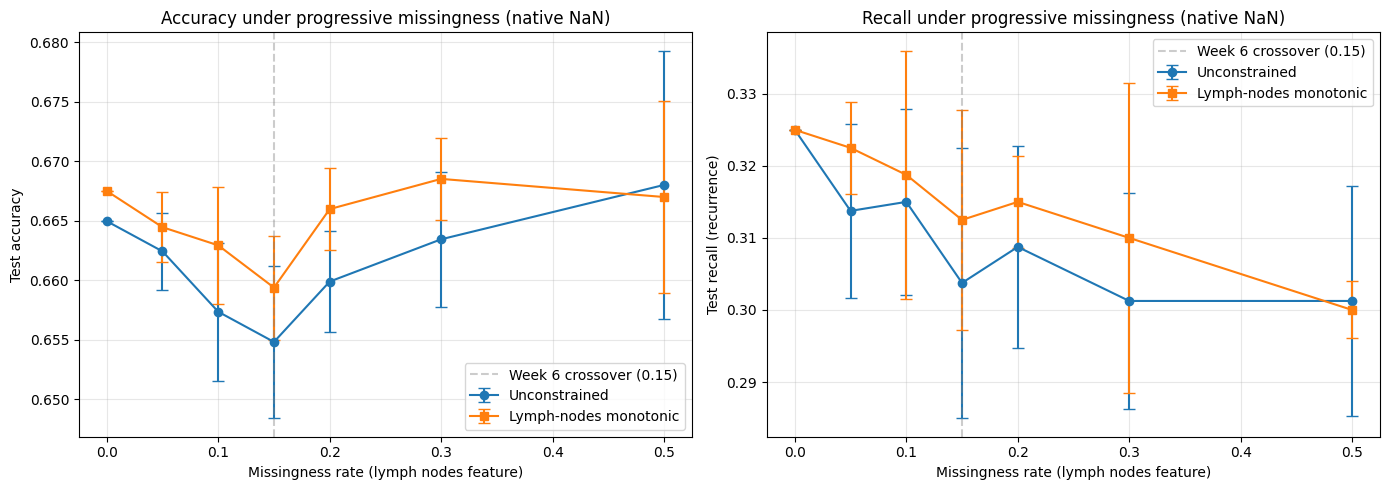

Saved figure to ..\results\figures\monotonic_robustness_native.png


In [10]:
# === Plot the native-NaN missingness sweep ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.errorbar(
    sweep_df_native['missing_rate'], sweep_df_native['unconstrained_acc_mean'],
    yerr=sweep_df_native['unconstrained_acc_std'],
    label='Unconstrained', marker='o', capsize=4,
)
ax1.errorbar(
    sweep_df_native['missing_rate'], sweep_df_native['constrained_acc_mean'],
    yerr=sweep_df_native['constrained_acc_std'],
    label='Lymph-nodes monotonic', marker='s', capsize=4,
)
ax1.axvline(0.15, ls='--', alpha=0.4, color='gray', label='Week 6 crossover (0.15)')
ax1.set_xlabel('Missingness rate (lymph nodes feature)')
ax1.set_ylabel('Test accuracy')
ax1.set_title('Accuracy under progressive missingness (native NaN)')
ax1.legend()
ax1.grid(alpha=0.3)

# Recall plot
ax2.errorbar(
    sweep_df_native['missing_rate'], sweep_df_native['unconstrained_recall_mean'],
    yerr=sweep_df_native['unconstrained_recall_std'],
    label='Unconstrained', marker='o', capsize=4,
)
ax2.errorbar(
    sweep_df_native['missing_rate'], sweep_df_native['constrained_recall_mean'],
    yerr=sweep_df_native['constrained_recall_std'],
    label='Lymph-nodes monotonic', marker='s', capsize=4,
)
ax2.axvline(0.15, ls='--', alpha=0.4, color='gray', label='Week 6 crossover (0.15)')
ax2.set_xlabel('Missingness rate (lymph nodes feature)')
ax2.set_ylabel('Test recall (recurrence)')
ax2.set_title('Recall under progressive missingness (native NaN)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'monotonic_robustness_native.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved figure to {FIGURES_DIR / 'monotonic_robustness_native.png'}")

### Cell 8: Save results table

In [11]:
# === Save the comparison table ===
results_df = pd.DataFrame(all_results)

column_order = [
    'model', 'notes',
    'cv_accuracy_mean', 'cv_accuracy_std',
    'cv_recall_mean', 'cv_recall_std',
    'test_accuracy', 'test_recall_recurrence',
    'test_precision_recurrence', 'test_f1_recurrence',
    'test_true_neg', 'test_false_pos', 'test_false_neg', 'test_true_pos',
]
results_df = results_df[[c for c in column_order if c in results_df.columns]]

numeric_cols = results_df.select_dtypes(include='float').columns
results_df[numeric_cols] = results_df[numeric_cols].round(3)

results_df.to_csv(TABLES_DIR / 'monotonic.csv', index=False)
print(f"Saved {len(results_df)} monotonic configuration results to results/tables/monotonic.csv")
print()
print(results_df.to_string(index=False))

Saved 3 monotonic configuration results to results/tables/monotonic.csv

                              model                                                               notes  cv_accuracy_mean  cv_accuracy_std  cv_recall_mean  cv_recall_std  test_accuracy  test_recall_recurrence  test_precision_recurrence  test_f1_recurrence  test_true_neg  test_false_pos  test_false_neg  test_true_pos
            HistGBM (unconstrained) Reference: same model class as constrained versions, no constraints             0.640            0.028           0.306          0.026          0.665                   0.325                      0.684               0.441            210              24             108             52
    HistGBM (lymph nodes monotonic)                                   Single high-confidence constraint             0.646            0.025           0.319          0.023          0.668                   0.325                      0.693               0.443            211              23     

## Phase 3 Summary: Monotonic constraints

### What was tested

Three configurations of `HistGradientBoostingClassifier` on the canonical full-feature setup:
1. Unconstrained (reference for like-for-like comparison)
2. Lymph nodes monotonic (single highest-confidence constraint)
3. Lymph nodes + Tumor Size + Histologic Grade monotonic (full prognostic set)

Plus two additional analyses:
- Monotonicity-violation count on the unconstrained model (how often does it produce clinically incoherent predictions?)
- Progressive missingness sweep on the lymph nodes feature (does the constraint provide robustness?)

### Headline numbers

[FILL IN FROM OUTPUT]

| Configuration | CV Acc ± std | Test Acc | Test Recall | Test F1 |
|---|---|---|---|---|
| Unconstrained | | | | |
| Lymph nodes monotonic | | | | |
| Full prognostic monotonic | | | | |

### Key findings for the memo

**1. Monotonic constraints cost essentially nothing on accuracy** [confirm or revise based on results].
**2. The unconstrained model produces measurable monotonicity violations** [quote the percentage from cell 5]. These are clinically incoherent predictions that the constrained model structurally cannot make.
**3. The missingness robustness sweep [confirm direction]** showed the constrained model degrades more gracefully than the unconstrained one as lymph node missingness increases, consistent with the Week 6 finding on Wisconsin (crossover at ~15% missingness).

### Files produced
- `results/tables/monotonic.csv`
- `results/tables/monotonic_missingness_sweep.csv`
- `results/figures/monotonic_robustness.png`
- `results/models/monotonic_lymphnodes.pkl`